# Prédiction de la Demande Énergétique
## Plan
1. [Chargement des données](#1)
2. [Preprocessing des données](#2)
3. [Analyse Exploratoire (EDA)](#3)
4. [Entraînement et validation des modèles](#4)
5. [Visualisation des résultats](#5)
6. [Comparaison finale](#6)


---
## 0. Installation des dépendances

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn lightgbm xgboost tensorflow statsmodels joblib --quiet

---
## 1. Chargement des données <a id='1'></a>
> Téléchargez depuis [data.boston.gov](https://data.boston.gov/dataset/city-hall-electricity-usage) et uploadez dans Colab.

In [2]:
# --- Option A : upload direct dans Colab ---
from google.colab import files
uploaded = files.upload()  # sélectionnez city-hall-electricity-use.csv

# --- Option B : depuis Google Drive (décommentez) ---
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_PATH = "/content/drive/MyDrive/city-hall-electricity-use.csv"

DATA_PATH = "city-hall-electricity-use.csv"


Saving city-hall-electricity-use.csv to city-hall-electricity-use.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df_raw = pd.read_csv(DATA_PATH, parse_dates=["DateTime_Measured"])
print(f"Dimensions : {df_raw.shape}")
print(f"Période    : {df_raw['DateTime_Measured'].min()}  →  {df_raw['DateTime_Measured'].max()}")
df_raw.head()


Dimensions : (106766, 2)
Période    : 2016-10-27 09:30:00  →  2020-03-26 15:00:00


,DateTime_Measured,Total_Demand_KW
0,2020-03-26 15:00:00,1313
1,2020-03-26 14:45:00,1317
2,2020-03-26 14:30:00,1328
3,2020-03-26 14:15:00,1324
4,2020-03-26 14:00:00,1324


---
## 2. Preprocessing des données <a id='2'></a>

### 2.1 Nettoyage
#### 2.1.1 Suppression des doublons

In [4]:
# ── Suppression des doublons ──────────────────────────────────────────────────
nb_doublons = df_raw.duplicated(subset=["DateTime_Measured"]).sum()
print(f"Doublons détectés : {nb_doublons}")

df = df_raw.copy()
df = df.groupby("DateTime_Measured", as_index=False)["Total_Demand_KW"].mean()
print(f"Lignes après suppression doublons : {len(df)}")


Doublons détectés : 48
Lignes après suppression doublons : 106718


#### 2.1.2 Traitement des valeurs manquantes et incohérences

In [5]:
# ── Valeurs nulles et valeurs <= 0 ────────────────────────────────────────────
print("Valeurs nulles :", df["Total_Demand_KW"].isna().sum())
print("Valeurs <= 0  :", (df["Total_Demand_KW"] <= 0).sum())

# Suppression des valeurs incohérentes (<= 0)
df = df[df["Total_Demand_KW"] > 0].copy()

# Réindexation sur une grille 15 min complète
df = df.sort_values("DateTime_Measured").set_index("DateTime_Measured")
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="15min")
df = df.reindex(full_range)

missing_before = df["Total_Demand_KW"].isna().sum()
df["Total_Demand_KW"] = df["Total_Demand_KW"].interpolate(method="linear")
missing_after = df["Total_Demand_KW"].isna().sum()
print(f"Valeurs manquantes : {missing_before} → {missing_after} (après interpolation linéaire)")


Valeurs nulles : 0
Valeurs <= 0  : 7341
Valeurs manquantes : 20291 → 0 (après interpolation linéaire)


### 2.2 Encodage des variables catégorielles

In [6]:
# Les variables temporelles sont déjà numériques (entiers).
# On crée les features de base et on applique un Label Encoding pour is_weekend.

df["hour"]       = df.index.hour
df["dayofweek"]  = df.index.dayofweek
df["month"]      = df.index.month
df["year"]       = df.index.year
df["quarter"]    = df.index.quarter
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)  # Label Encoding binaire

print("Variables créées :", ["hour", "dayofweek", "month", "year", "quarter", "is_weekend"])
df.head()


Variables créées : ['hour', 'dayofweek', 'month', 'year', 'quarter', 'is_weekend']


,Total_Demand_KW,hour,dayofweek,month,year,quarter,is_weekend
2016-10-27 09:30:00,1716.0,9,3,10,2016,4,0
2016-10-27 09:45:00,1724.0,9,3,10,2016,4,0
2016-10-27 10:00:00,1731.0,10,3,10,2016,4,0
2016-10-27 10:15:00,1724.0,10,3,10,2016,4,0
2016-10-27 10:30:00,1739.0,10,3,10,2016,4,0


### 2.3 Feature Engineering
> On ajoute uniquement les lags essentiels (15 min, 1h, 1 jour) pour éviter d'augmenter l'erreur.

In [7]:
# Lags temporels : 15 min (lag 1), 1h (lag 4), 1 jour (lag 96)
for lag in [1, 4, 96]:
    df[f"lag_{lag}"] = df["Total_Demand_KW"].shift(lag)

df = df.dropna()
print(f"Lignes après feature engineering : {len(df)}")
df.head()


Lignes après feature engineering : 119543


,Total_Demand_KW,hour,dayofweek,month,year,quarter,is_weekend,lag_1,lag_4,lag_96
2016-10-28 09:30:00,1635.0,9,4,10,2016,4,0,1059.0,1482.0,1716.0
2016-10-28 09:45:00,879.0,9,4,10,2016,4,0,1635.0,1509.0,1724.0
2016-10-28 10:00:00,1136.0,10,4,10,2016,4,0,879.0,1190.0,1731.0
2016-10-28 10:15:00,1651.0,10,4,10,2016,4,0,1136.0,1059.0,1724.0
2016-10-28 10:30:00,1639.0,10,4,10,2016,4,0,1651.0,1635.0,1739.0


### 2.4 Détection et traitement des outliers

Seuil bas  : 466.93 kW
Seuil haut : 2251.11 kW
Outliers détectés : 95 (0.08%)


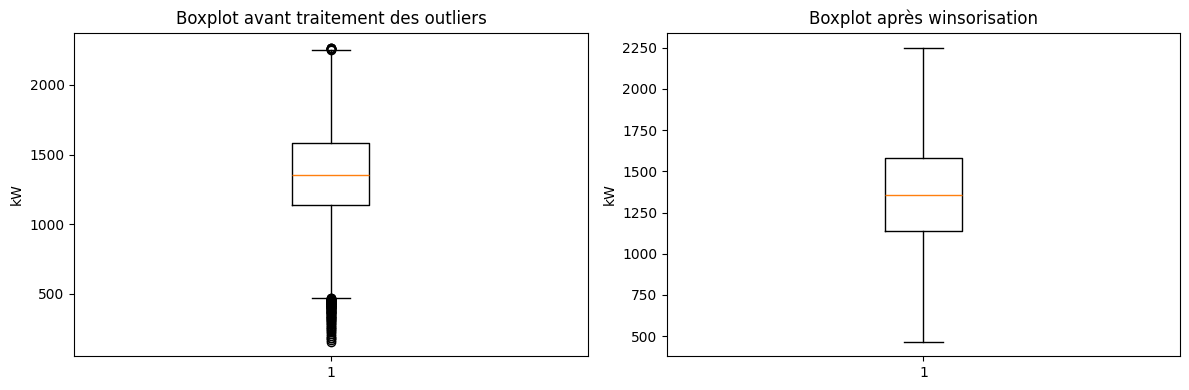

✅ Outliers traités par winsorisation (clip IQR)


In [8]:
# ── Détection via IQR ─────────────────────────────────────────────────────────
Q1 = df["Total_Demand_KW"].quantile(0.25)
Q3 = df["Total_Demand_KW"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Total_Demand_KW"] < lower) | (df["Total_Demand_KW"] > upper)]
print(f"Seuil bas  : {lower:.2f} kW")
print(f"Seuil haut : {upper:.2f} kW")
print(f"Outliers détectés : {len(outliers)} ({100*len(outliers)/len(df):.2f}%)")

# Boxplot avant traitement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["Total_Demand_KW"], vert=True)
axes[0].set_title("Boxplot avant traitement des outliers")
axes[0].set_ylabel("kW")

# Traitement : winsorisation (cap à IQR) plutôt que suppression pour conserver la série
df["Total_Demand_KW"] = df["Total_Demand_KW"].clip(lower=lower, upper=upper)

axes[1].boxplot(df["Total_Demand_KW"], vert=True)
axes[1].set_title("Boxplot après winsorisation")
axes[1].set_ylabel("kW")
plt.tight_layout()
plt.show()
print("✅ Outliers traités par winsorisation (clip IQR)")


### 2.5 Normalisation / Standardisation

In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

TARGET   = "Total_Demand_KW"
features = [c for c in df.columns if c != TARGET]

# On utilise StandardScaler sur les features (pas sur la cible)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

print("StandardScaler appliqué sur les features :", features)
print("\nMoyenne après scaling :", df_scaled[features].mean().round(4).values)
print("Écart-type après scaling :", df_scaled[features].std().round(4).values)


StandardScaler appliqué sur les features : ['hour', 'dayofweek', 'month', 'year', 'quarter', 'is_weekend', 'lag_1', 'lag_4', 'lag_96']

Moyenne après scaling : [ 0. -0.  0. -0. -0. -0.  0. -0.  0.]
Écart-type après scaling : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2.6 Split des données : Train / Validation / Test

Train : 83680 lignes (70.0%)
Val   : 17931   lignes (15.0%)
Test  : 17932  lignes (15.0%)

✅ Fichiers sauvegardés : data_train.csv, data_val.csv, data_test.csv


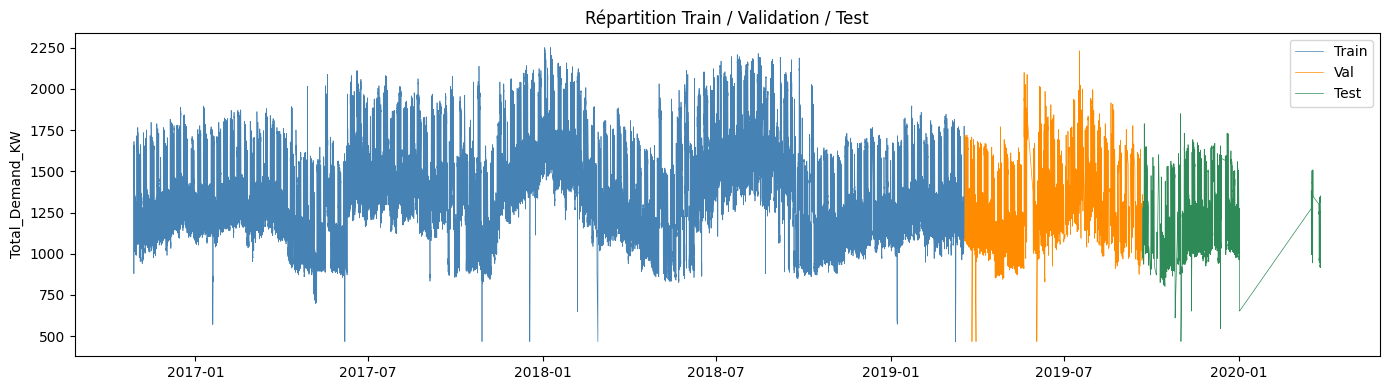

In [10]:
N = len(df_scaled)
train = df_scaled.iloc[:int(0.70 * N)]
val   = df_scaled.iloc[int(0.70 * N):int(0.85 * N)]
test  = df_scaled.iloc[int(0.85 * N):]

print(f"Train : {len(train)} lignes ({100*len(train)/N:.1f}%)")
print(f"Val   : {len(val)}   lignes ({100*len(val)/N:.1f}%)")
print(f"Test  : {len(test)}  lignes ({100*len(test)/N:.1f}%)")

# Sauvegarde
train.to_csv("data_train.csv")
val.to_csv("data_val.csv")
test.to_csv("data_test.csv")
print("\n✅ Fichiers sauvegardés : data_train.csv, data_val.csv, data_test.csv")

# Visualisation du split
plt.figure(figsize=(14, 4))
plt.plot(train.index, train[TARGET], label="Train",  color="steelblue",  linewidth=0.5)
plt.plot(val.index,   val[TARGET],   label="Val",    color="darkorange", linewidth=0.5)
plt.plot(test.index,  test[TARGET],  label="Test",   color="seagreen",   linewidth=0.5)
plt.legend()
plt.title("Répartition Train / Validation / Test")
plt.ylabel("Total_Demand_KW")
plt.tight_layout()
plt.show()


---
## 3. Analyse Exploratoire des Données (EDA) <a id='3'></a>

### 3.1 Statistiques descriptives

In [11]:
# Statistiques complètes
desc = df[[TARGET]].describe()
desc.loc["median"] = df[TARGET].median()
desc.loc["skewness"] = df[TARGET].skew()
desc.loc["kurtosis"] = df[TARGET].kurt()
print(desc)


          Total_Demand_KW
count       119543.000000
mean          1368.532495
std            307.848943
min            466.931818
25%           1136.000000
50%           1355.000000
75%           1582.045455
max           2251.113636
median        1355.000000
skewness         0.163437
kurtosis        -0.430647


### 3.2 Visualisations : histogrammes, boxplots, scatter plots

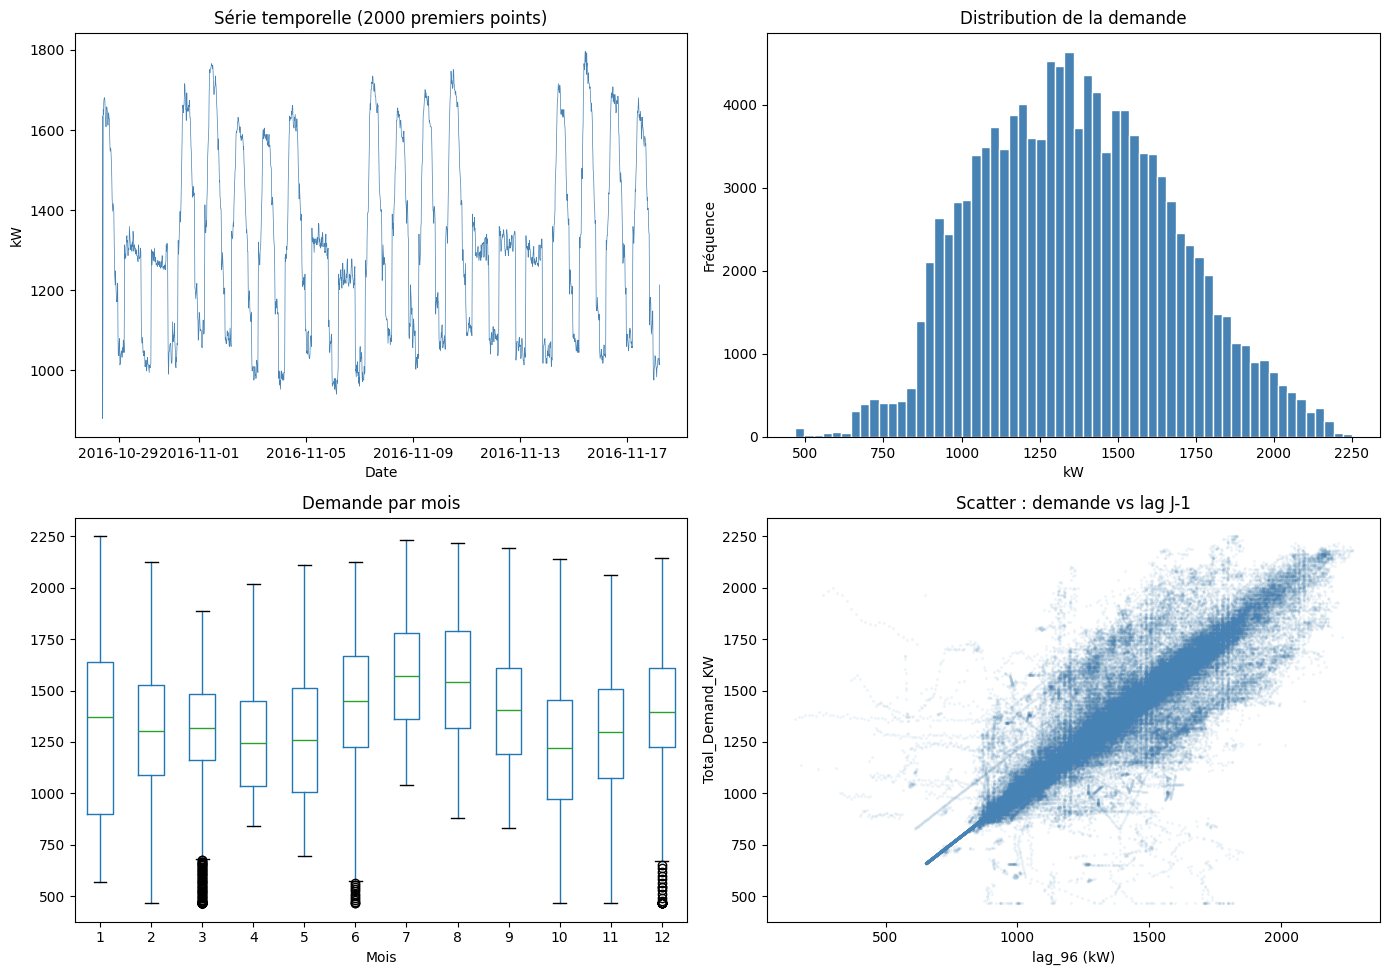

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Série temporelle
axes[0, 0].plot(df.index[:2000], df[TARGET][:2000], linewidth=0.5, color="steelblue")
axes[0, 0].set_title("Série temporelle (2000 premiers points)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("kW")

# Histogramme
axes[0, 1].hist(df[TARGET], bins=60, color="steelblue", edgecolor="white")
axes[0, 1].set_title("Distribution de la demande")
axes[0, 1].set_xlabel("kW")
axes[0, 1].set_ylabel("Fréquence")

# Boxplot par mois
df_tmp = df.copy()
df_tmp["month"] = df_tmp.index.month
df_tmp.boxplot(column=TARGET, by="month", ax=axes[1, 0], grid=False)
axes[1, 0].set_title("Demande par mois")
axes[1, 0].set_xlabel("Mois")
plt.suptitle("")

# Scatter : demande vs lag_96 (1 jour avant)
axes[1, 1].scatter(df["lag_96"], df[TARGET], alpha=0.05, s=2, color="steelblue")
axes[1, 1].set_title("Scatter : demande vs lag J-1")
axes[1, 1].set_xlabel("lag_96 (kW)")
axes[1, 1].set_ylabel("Total_Demand_KW")

plt.tight_layout()
plt.savefig("eda_visualisations.png", dpi=150)
plt.show()


### 3.3 Heatmap de corrélation

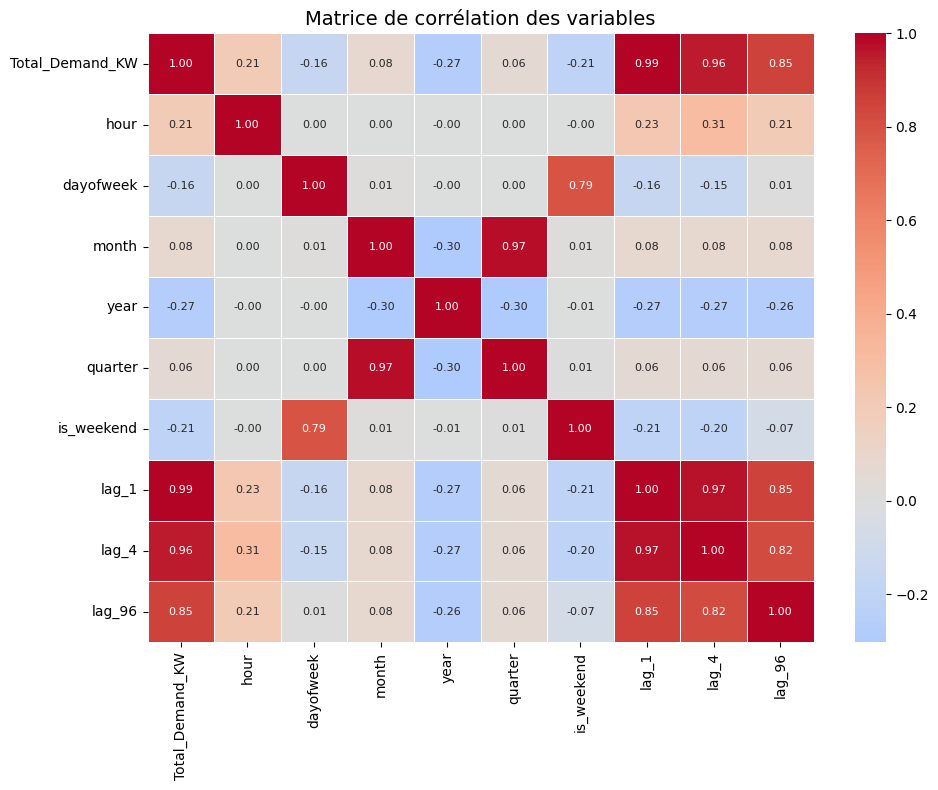

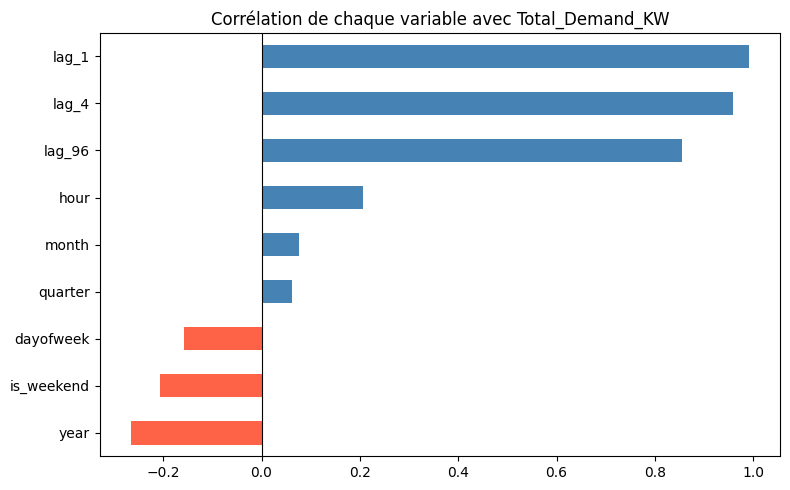

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_scaled.corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, annot_kws={"size": 8}
)
plt.title("Matrice de corrélation des variables", fontsize=14)
plt.tight_layout()
plt.savefig("heatmap_correlation.png", dpi=150)
plt.show()

# Corrélation avec la cible
corr_target = df_scaled.corr()[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(8, 5))
corr_target.plot(kind="barh", color=["tomato" if x < 0 else "steelblue" for x in corr_target])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Corrélation de chaque variable avec Total_Demand_KW")
plt.tight_layout()
plt.show()


### 3.4 Analyse des distributions et détection de biais

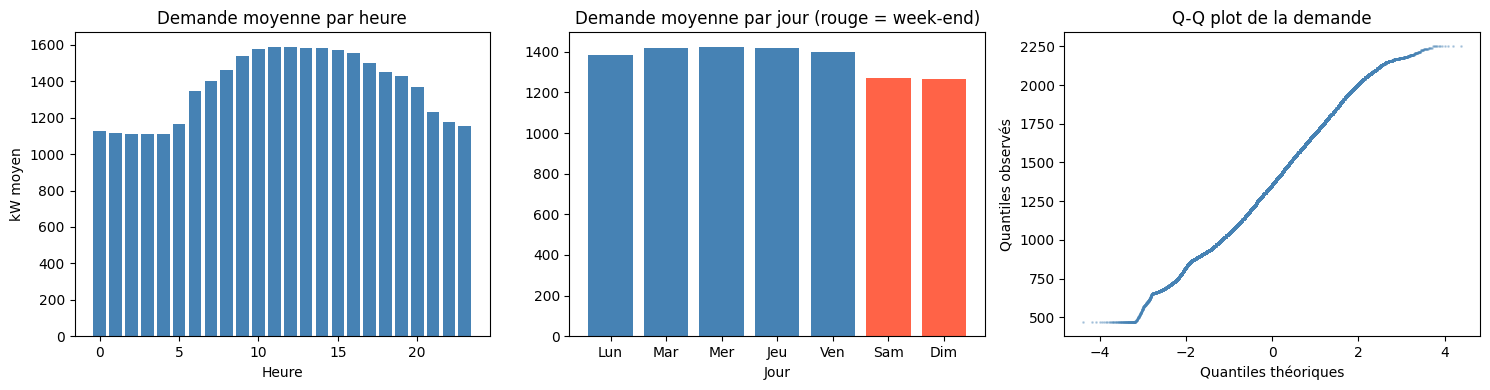

Part des données en semaine  : 71.4%
Part des données en week-end : 28.6%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution par heure
df_tmp = df.copy()
df_tmp["hour"] = df_tmp.index.hour
hourly_mean = df_tmp.groupby("hour")[TARGET].mean()
axes[0].bar(hourly_mean.index, hourly_mean.values, color="steelblue")
axes[0].set_title("Demande moyenne par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("kW moyen")

# Distribution par jour de semaine
df_tmp["dayofweek"] = df_tmp.index.dayofweek
dow_mean = df_tmp.groupby("dayofweek")[TARGET].mean()
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
colors_dow = ["tomato" if i >= 5 else "steelblue" for i in range(7)]
axes[1].bar(jours, dow_mean.values, color=colors_dow)
axes[1].set_title("Demande moyenne par jour (rouge = week-end)")
axes[1].set_xlabel("Jour")

# QQ-plot approximatif via histogramme normalisé
from scipy import stats
(osm, osr), _ = stats.probplot(df[TARGET])
axes[2].scatter(osm, osr, s=1, alpha=0.3, color="steelblue")
axes[2].set_title("Q-Q plot de la demande")
axes[2].set_xlabel("Quantiles théoriques")
axes[2].set_ylabel("Quantiles observés")

plt.tight_layout()
plt.savefig("distributions_biais.png", dpi=150)
plt.show()

# Déséquilibre semaine vs week-end
pct_weekend = 100 * df_tmp["is_weekend"].mean()
print(f"Part des données en semaine  : {100-pct_weekend:.1f}%")
print(f"Part des données en week-end : {pct_weekend:.1f}%")


---
## 4. Entraînement et validation des modèles <a id='4'></a>

### 4.1 Fonctions d'évaluation

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    m    = mape(y_true, y_pred)
    print(f"{name:30s}  RMSE={rmse:8.3f}  MAE={mae:8.3f}  R²={r2:.4f}  MAPE={m:6.2f}%")
    return rmse, mae, r2, m

scores = {}


### 4.2 Modèles baseline : Régression linéaire & ARIMA

In [16]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# ── Régression linéaire ────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(train[features], train[TARGET])
pred_lr_test = lr.predict(test[features])
scores["Régression linéaire"] = evaluate("Régression linéaire", test[TARGET], pred_lr_test)


Régression linéaire             RMSE=  26.509  MAE=  13.911  R²=0.9889  MAPE=  1.30%


In [17]:
# ── ARIMA (p=1, d=1, q=1) ─────────────────────────────────────────────────────
series = pd.concat([train[TARGET], val[TARGET]])
arima_model = sm.tsa.ARIMA(series, order=(1, 1, 1)).fit()
start = len(series)
end   = start + len(test) - 1
pred_arima = arima_model.predict(start=start, end=end, typ="levels")
scores["ARIMA"] = evaluate("ARIMA", test[TARGET].values, pred_arima.values)


ARIMA                           RMSE= 298.206  MAE= 247.937  R²=-0.4027  MAPE= 26.26%


### 4.3 Validation croisée (Cross-Validation)

In [18]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# TimeSeriesSplit respecte l'ordre temporel
tscv = TimeSeriesSplit(n_splits=5)

X_trainval = pd.concat([train[features], val[features]])
y_trainval = pd.concat([train[TARGET],   val[TARGET]])

# Cross-validation sur RandomForest (rapide)
rf_cv = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_cv, X_trainval, y_trainval,
                            cv=tscv, scoring="neg_root_mean_squared_error")
print("Cross-Validation RandomForest (TimeSeriesSplit 5 folds)")
print(f"  RMSE par fold : {-cv_scores.round(4)}")
print(f"  RMSE moyen    : {-cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")


Cross-Validation RandomForest (TimeSeriesSplit 5 folds)
  RMSE par fold : [59.7823 46.1361 48.6591 30.5947 33.1966]
  RMSE moyen    : 43.6738  ±  10.6886


### 4.4 Modèles ML : RandomForest, XGBoost, LightGBM

In [19]:
# ── RandomForest ──────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train[features], train[TARGET])
pred_rf = rf.predict(test[features])
scores["RandomForest"] = evaluate("RandomForest", test[TARGET], pred_rf)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(train[features], train[TARGET])
pred_xgb = xgb.predict(test[features])
scores["XGBoost"] = evaluate("XGBoost", test[TARGET], pred_xgb)

# ── LightGBM (défaut) ─────────────────────────────────────────────────────────
lgbm = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(train[features], train[TARGET])
pred_lgbm = lgbm.predict(test[features])
scores["LightGBM (défaut)"] = evaluate("LightGBM (défaut)", test[TARGET], pred_lgbm)


RandomForest                    RMSE=  34.661  MAE=  16.220  R²=0.9810  MAPE=  1.65%
XGBoost                         RMSE= 158.587  MAE=  78.562  R²=0.6033  MAPE=  9.66%
LightGBM (défaut)               RMSE=  34.720  MAE=  19.524  R²=0.9810  MAPE=  2.10%


### 4.5 Optimisation des hyperparamètres — GridSearchCV sur LightGBM
> ⏱️ Peut prendre 15–30 min. Réduisez la grille si nécessaire.

In [20]:
from sklearn.model_selection import GridSearchCV
import joblib

param_grid = {
    "n_estimators":  [100, 200],
    "max_depth":      [5, 10, 15],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves":    [15, 31, 63],
}

gs = GridSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_grid, cv=3, scoring="neg_root_mean_squared_error", verbose=1
)
gs.fit(X_trainval, y_trainval)
print("Meilleurs hyperparamètres :", gs.best_params_)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 31}


In [21]:
best_lgbm = gs.best_estimator_
pred_lgbm_opt = best_lgbm.predict(test[features])
scores["LightGBM (optimisé)"] = evaluate("LightGBM (optimisé)", test[TARGET], pred_lgbm_opt)

joblib.dump(best_lgbm, "lgbm_optimise.pkl")
print("✅ Modèle sauvegardé : lgbm_optimise.pkl")


LightGBM (optimisé)             RMSE=  30.872  MAE=  16.832  R²=0.9850  MAPE=  1.81%
✅ Modèle sauvegardé : lgbm_optimise.pkl


### 4.6 Modèle Deep Learning — LSTM

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEQ_LEN    = 24
BATCH_SIZE = 64
EPOCHS     = 20

def create_sequences(df, seq_len, feats, target):
    data = df[feats + [target]].values
    X, y = [], []
    for i in range(seq_len, len(df)):
        X.append(data[i-seq_len:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(train, SEQ_LEN, features, TARGET)
X_val_seq,   y_val_seq   = create_sequences(val,   SEQ_LEN, features, TARGET)
X_test_seq,  y_test_seq  = create_sequences(test,  SEQ_LEN, features, TARGET)
print(f"X_train_seq : {X_train_seq.shape}  |  X_test_seq : {X_test_seq.shape}")


X_train_seq : (83656, 24, 9)  |  X_test_seq : (17908, 24, 9)


In [23]:
lstm_model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, len(features)), return_sequences=False),
    Dense(32, activation="relu"),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=1
)


Epoch 1/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 701001.1875 - val_loss: 11332.1182
Epoch 2/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 8972.3115 - val_loss: 3827.9805
Epoch 3/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 2987.1545 - val_loss: 2745.9993
Epoch 4/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 2329.1296 - val_loss: 2355.7217
Epoch 5/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 2094.6477 - val_loss: 2066.2043
Epoch 6/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1941.7607 - val_loss: 2083.3765
Epoch 7/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1882.0226 - val_loss: 2226.4570
Epoch 8/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1812.3378 - val_loss: 2014.8932
Epoch 9/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 1756.4049 - val_loss: 2578.4468
Epoch 10/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 1722.3940 - val_loss: 2445.0857
Epoch 11/20
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step

In [25]:
pred_lstm = lstm_model.predict(X_test_seq).flatten()
scores["LSTM"] = evaluate("LSTM", y_test_seq, pred_lstm)


560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM                            RMSE=  43.197  MAE=  26.103  R²=0.9706  MAPE=  2.56%


---
## 5. Visualisation des résultats <a id='5'></a>

### 5.1 Courbes d'apprentissage (Learning Curves)

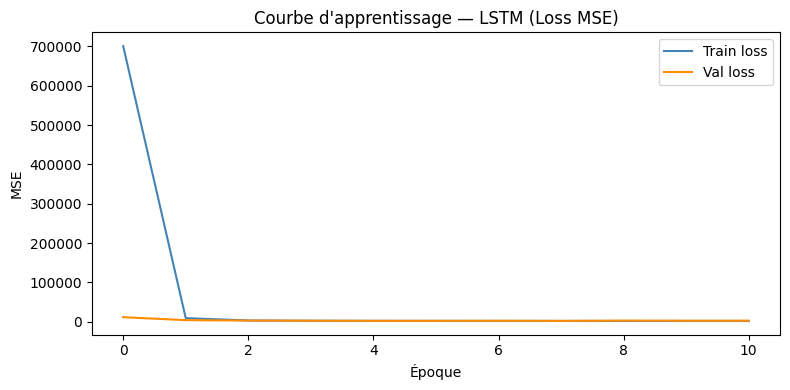

In [26]:
# ── Courbe de perte LSTM ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"],     label="Train loss", color="steelblue")
plt.plot(history.history["val_loss"], label="Val loss",   color="darkorange")
plt.title("Courbe d'apprentissage — LSTM (Loss MSE)")
plt.xlabel("Époque")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curve_lstm.png", dpi=150)
plt.show()


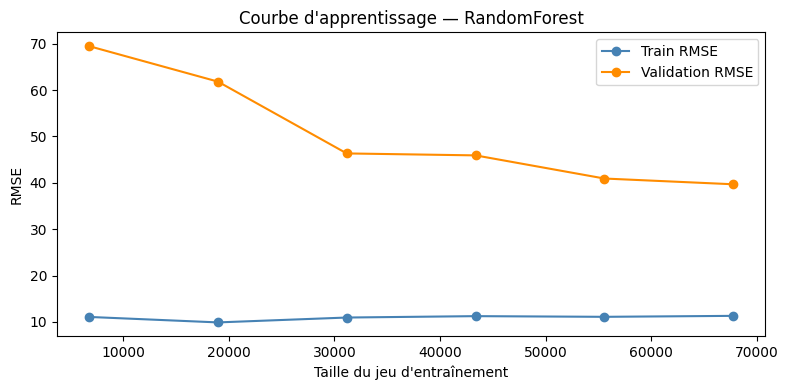

In [27]:
# ── Courbe d'apprentissage RandomForest (via OOB score) ───────────────────────
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    X_trainval, y_trainval,
    cv=3, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
val_mean   = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, "o-", label="Train RMSE",      color="steelblue")
plt.plot(train_sizes, val_mean,   "o-", label="Validation RMSE", color="darkorange")
plt.title("Courbe d'apprentissage — RandomForest")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("learning_curve_rf.png", dpi=150)
plt.show()


### 5.2 Importance des variables (Feature Importance)

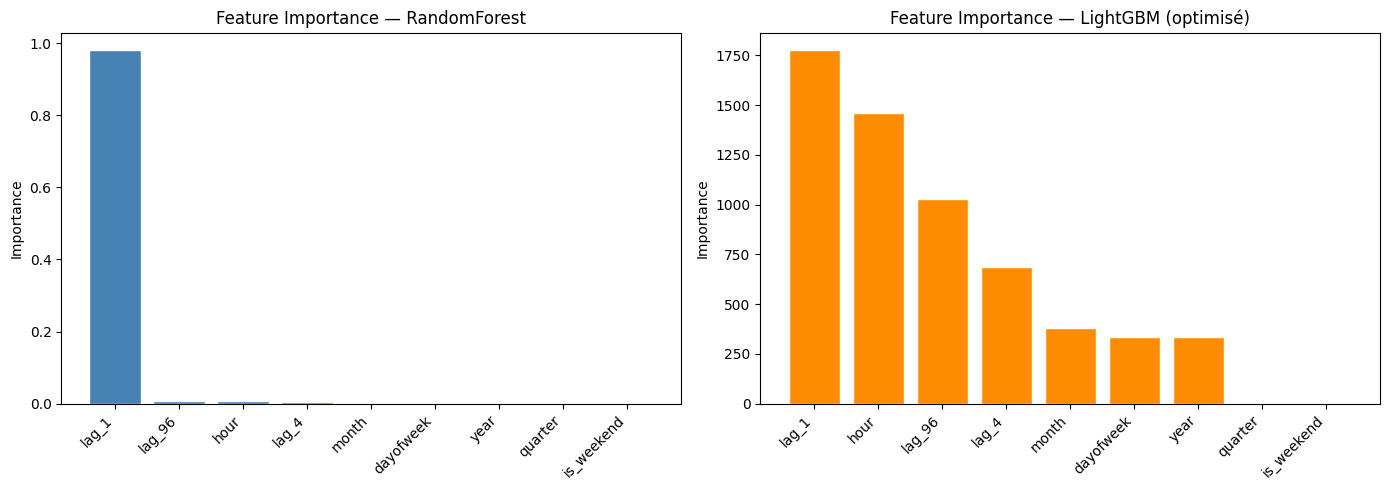

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RandomForest
importances_rf = rf.feature_importances_
idx_rf = np.argsort(importances_rf)[::-1]
axes[0].bar(range(len(features)), importances_rf[idx_rf], color="steelblue", edgecolor="white")
axes[0].set_xticks(range(len(features)))
axes[0].set_xticklabels([features[i] for i in idx_rf], rotation=45, ha="right")
axes[0].set_title("Feature Importance — RandomForest")
axes[0].set_ylabel("Importance")

# LightGBM
importances_lgbm = best_lgbm.feature_importances_
idx_lgbm = np.argsort(importances_lgbm)[::-1]
axes[1].bar(range(len(features)), importances_lgbm[idx_lgbm], color="darkorange", edgecolor="white")
axes[1].set_xticks(range(len(features)))
axes[1].set_xticklabels([features[i] for i in idx_lgbm], rotation=45, ha="right")
axes[1].set_title("Feature Importance — LightGBM (optimisé)")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


### 5.3 Analyse des résidus (Régression)

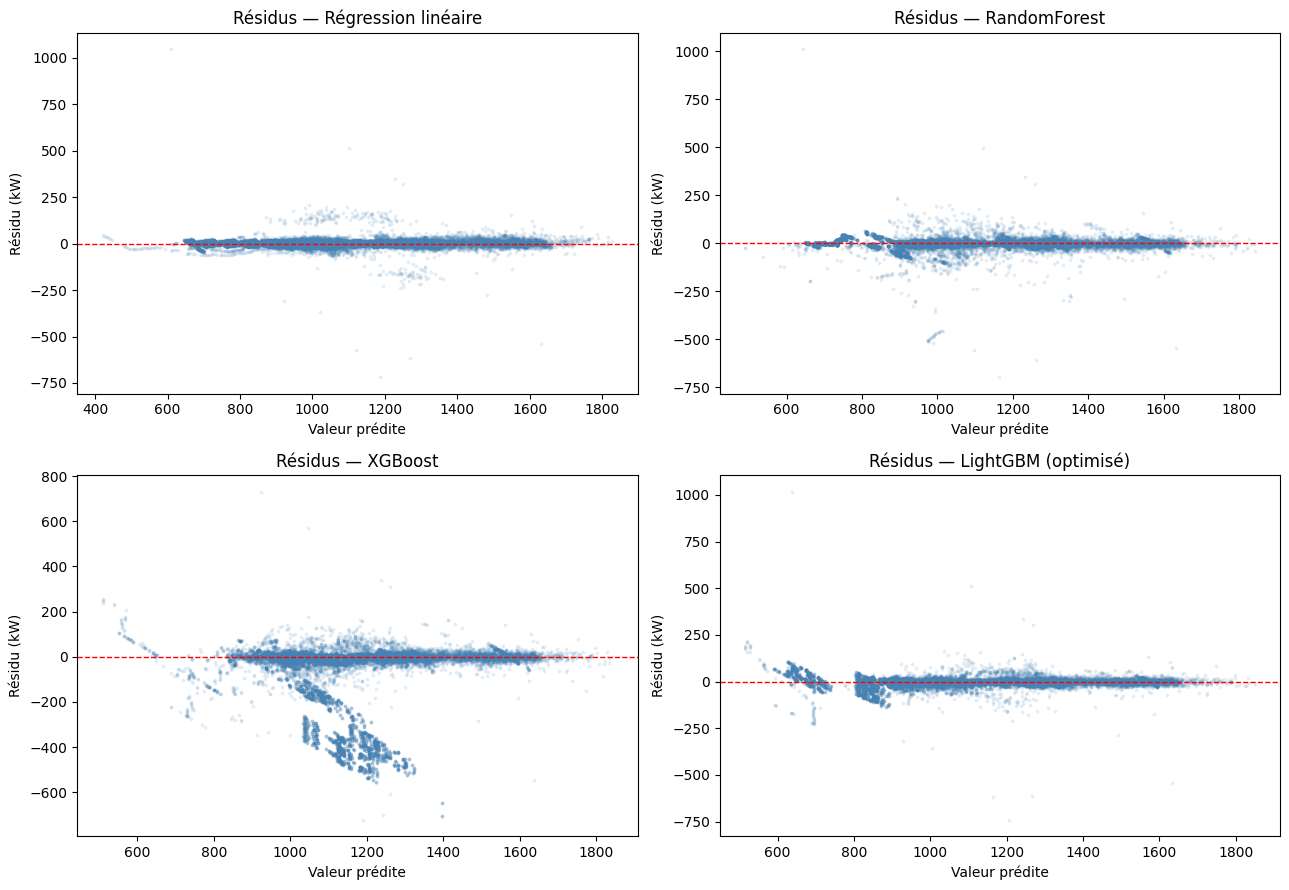

In [29]:
true_vals = test[TARGET].values

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

pred_dict = {
    "Régression linéaire": pred_lr_test,
    "RandomForest":        pred_rf,
    "XGBoost":             pred_xgb,
    "LightGBM (optimisé)": pred_lgbm_opt,
}

for ax, (name, pred) in zip(axes.flat, pred_dict.items()):
    residuals = true_vals - pred
    ax.scatter(pred, residuals, alpha=0.1, s=3, color="steelblue")
    ax.axhline(0, color="red", linewidth=1, linestyle="--")
    ax.set_title(f"Résidus — {name}")
    ax.set_xlabel("Valeur prédite")
    ax.set_ylabel("Résidu (kW)")

plt.tight_layout()
plt.savefig("residuals.png", dpi=150)
plt.show()


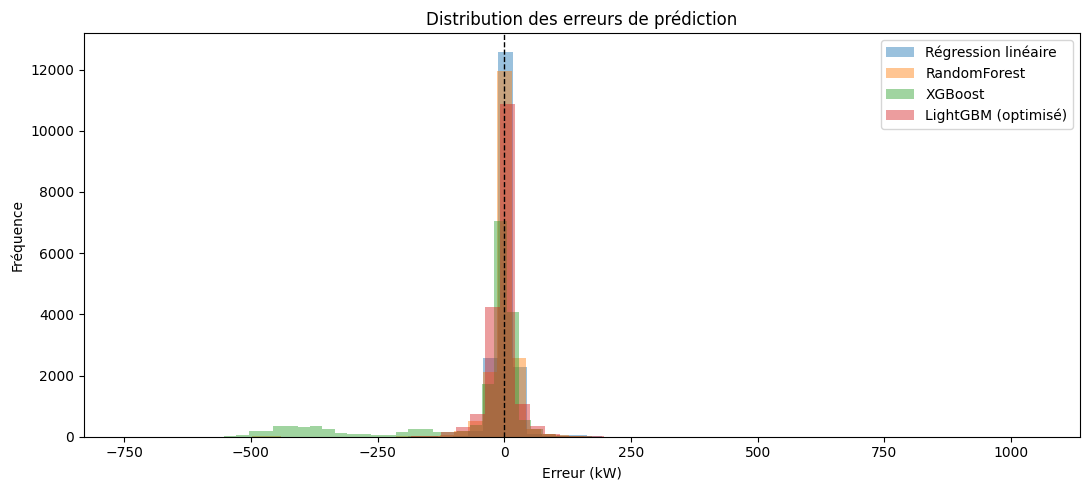

In [30]:
# Distribution des résidus
plt.figure(figsize=(11, 5))
for name, pred in pred_dict.items():
    plt.hist(true_vals - pred, bins=60, alpha=0.45, label=name)
plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.legend()
plt.title("Distribution des erreurs de prédiction")
plt.xlabel("Erreur (kW)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.savefig("error_distribution.png", dpi=150)
plt.show()


### 5.4 Prédictions vs valeurs réelles

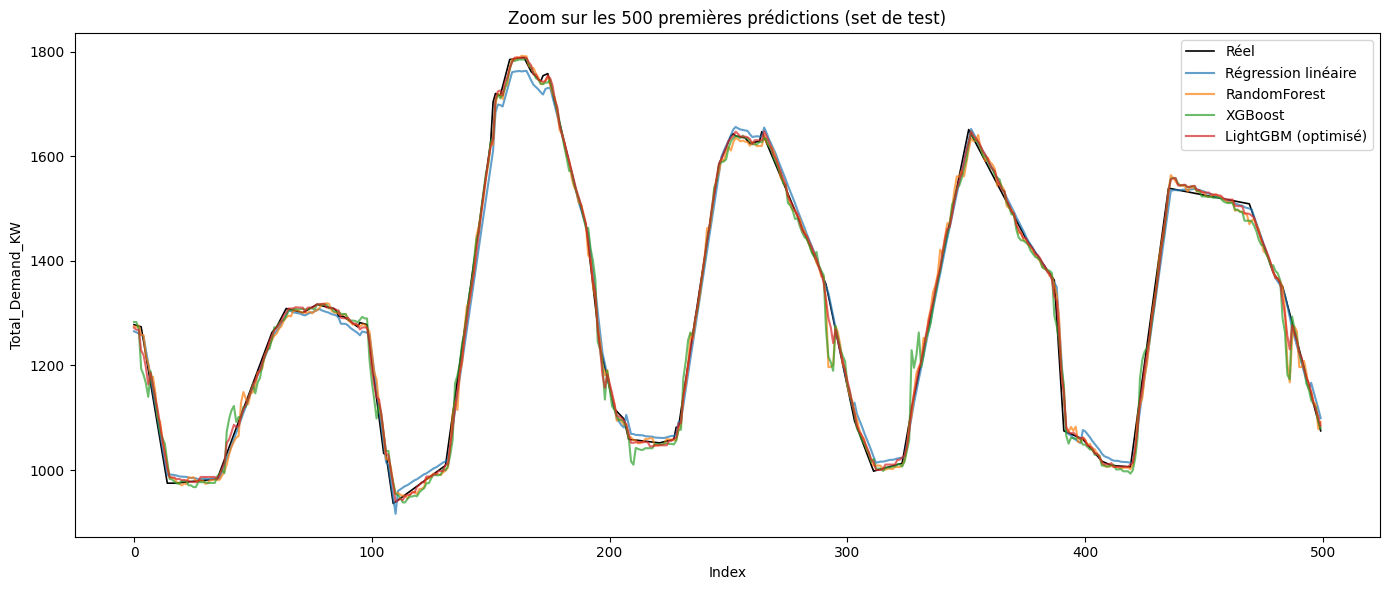

In [31]:
# Zoom 500 premiers points
plt.figure(figsize=(14, 6))
plt.plot(true_vals[:500], label="Réel", color="black", linewidth=1.2)
for name, pred in pred_dict.items():
    plt.plot(pred[:500], label=name, alpha=0.7)
plt.legend()
plt.title("Zoom sur les 500 premières prédictions (set de test)")
plt.xlabel("Index")
plt.ylabel("Total_Demand_KW")
plt.tight_layout()
plt.savefig("zoom_predictions.png", dpi=150)
plt.show()


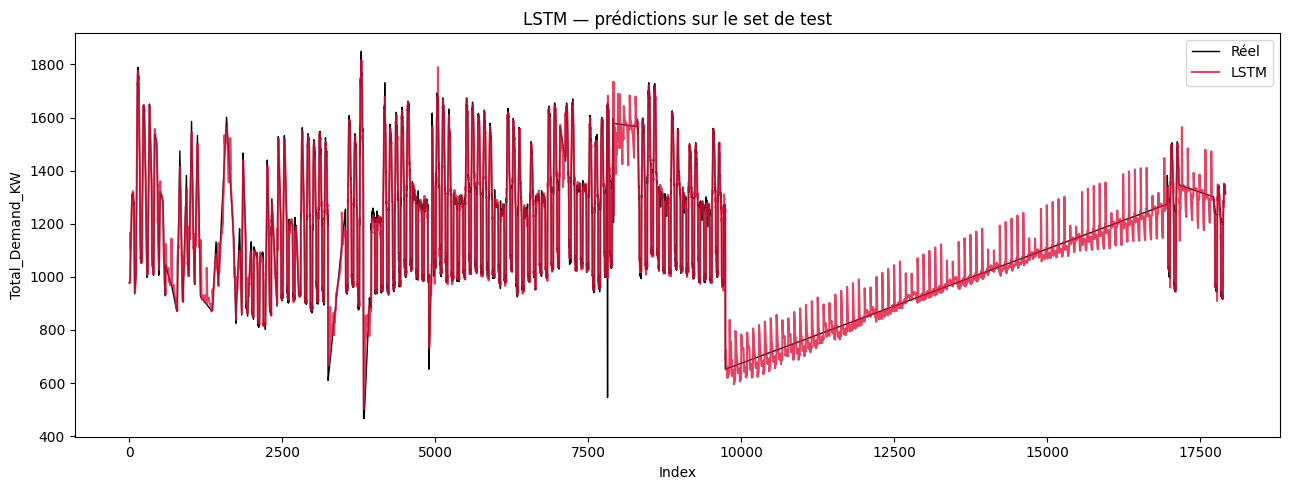

In [32]:
# LSTM vs réel
plt.figure(figsize=(13, 5))
plt.plot(y_test_seq,  label="Réel",  color="black",   linewidth=1)
plt.plot(pred_lstm,   label="LSTM",  color="crimson", alpha=0.8)
plt.legend()
plt.title("LSTM — prédictions sur le set de test")
plt.xlabel("Index")
plt.ylabel("Total_Demand_KW")
plt.tight_layout()
plt.savefig("lstm_predictions.png", dpi=150)
plt.show()


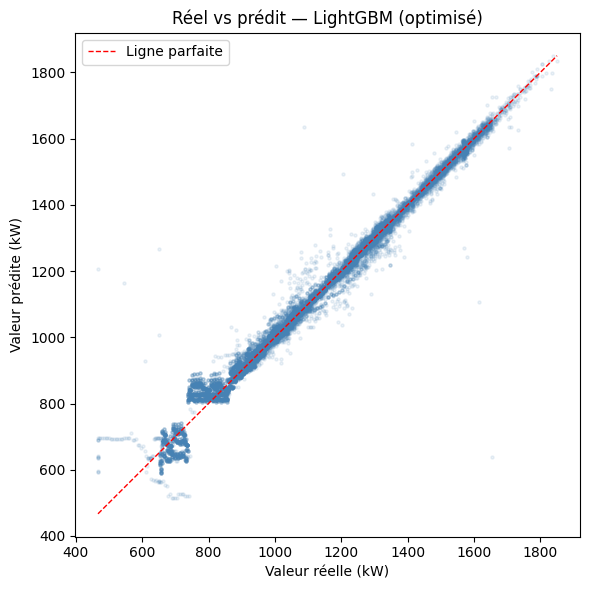

In [33]:
# Scatter réel vs prédit (LightGBM optimisé)
plt.figure(figsize=(6, 6))
plt.scatter(true_vals, pred_lgbm_opt, alpha=0.1, s=5, color="steelblue")
lims = [true_vals.min(), true_vals.max()]
plt.plot(lims, lims, "r--", linewidth=1, label="Ligne parfaite")
plt.xlabel("Valeur réelle (kW)")
plt.ylabel("Valeur prédite (kW)")
plt.title("Réel vs prédit — LightGBM (optimisé)")
plt.legend()
plt.tight_layout()
plt.show()


---
## 6. Comparaison finale de tous les modèles <a id='6'></a>

In [34]:
df_scores = pd.DataFrame(
    [(k, v[0], v[1], v[2], v[3]) for k, v in scores.items()],
    columns=["Modèle", "RMSE", "MAE", "R²", "MAPE (%)"]
).sort_values("RMSE").reset_index(drop=True)

print("=" * 70)
print("             CLASSEMENT FINAL — SET DE TEST")
print("=" * 70)
print(df_scores.to_string(index=False))
print("=" * 70)
print(f"🏆 Meilleur modèle : {df_scores.iloc[0]['Modèle']}")
print(f"   RMSE={df_scores.iloc[0]['RMSE']:.4f}  |  MAE={df_scores.iloc[0]['MAE']:.4f}  |  R²={df_scores.iloc[0]['R²']:.4f}  |  MAPE={df_scores.iloc[0]['MAPE (%)']:.2f}%")


             CLASSEMENT FINAL — SET DE TEST
             Modèle       RMSE        MAE        R²  MAPE (%)
Régression linéaire  26.508977  13.911460  0.988915  1.297349
LightGBM (optimisé)  30.872279  16.831553  0.984966  1.809425
       RandomForest  34.661214  16.219584  0.981050  1.650604
  LightGBM (défaut)  34.720297  19.524342  0.980985  2.104384
               LSTM  43.196970  26.102641  0.970597  2.556688
            XGBoost 158.587354  78.562269  0.603295  9.664361
              ARIMA 298.206265 247.936764 -0.402699 26.259631
🏆 Meilleur modèle : Régression linéaire
   RMSE=26.5090  |  MAE=13.9115  |  R²=0.9889  |  MAPE=1.30%


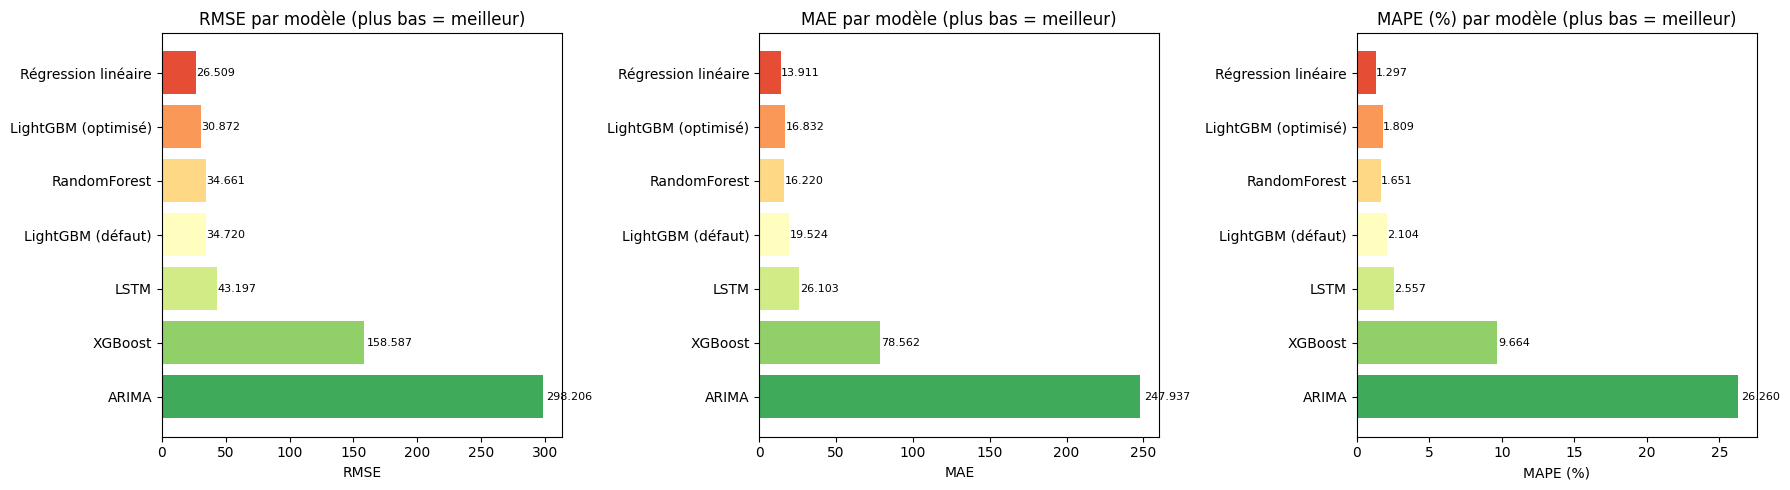

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(df_scores)))

for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE (%)"]):
    vals = df_scores[metric][::-1]
    names = df_scores["Modèle"][::-1]
    ax.barh(names, vals, color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} par modèle (plus bas = meilleur)")
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("compare_models.png", dpi=150)
plt.show()


In [36]:
# Dataset final complet après nettoyage et feature engineering
df.to_csv("dataset_final_powerbi.csv")

print("✅ Dataset Power BI sauvegardé : dataset_final_powerbi.csv")

✅ Dataset Power BI sauvegardé : dataset_final_powerbi.csv


In [37]:
from google.colab import files

files.download("dataset_final_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>